In [1]:
import pandas as pd
import numpy as np
import pybursts

from bursty_dynamics.scores import calculate_scores
from bursty_dynamics.trains import train_detection, train_info, train_scores
from bursty_dynamics.visual import *

In [2]:
episodes_with_id = pd.read_csv("../data/episodes_with_id.csv")
episodes_with_id = episodes_with_id[~episodes_with_id['category1'].isin(['religion', 'christianity'])]

print(f"Number of episodes: {len(episodes_with_id)}")

Number of episodes: 8127


In [3]:
episodes = []
num_dfs_appended = 0

for i in range(1, 11):
    for episode_id in episodes_with_id['episode_id']:
        file_path = f"../data/episodes/part_{i}/episode_{episode_id}.csv"
        try:
            df = pd.read_csv(file_path, usecols=lambda col: col in ['sentence', 'racialJustice', 'collectiveAction', 'collectiveActionMulti'])
            df['episode_id'] = episode_id  
            base_time = pd.to_datetime(episodes_with_id.loc[episodes_with_id['episode_id'] == episode_id, 'episodeDateLocalized'].values[0])
            df['time'] = base_time + pd.to_timedelta(df.index * 10, unit='s')
            if ((df['racialJustice'] == 1) & (df['collectiveAction'] == 0)).any():
                episodes.append(df) 
                num_dfs_appended += 1  
        except FileNotFoundError:
            continue

episodes = pd.concat(episodes, ignore_index=True)
print(f"Number of episodes with at least one RJ+CA sentence: {num_dfs_appended}")

Number of episodes with at least one RJ+CA sentence: 6366


In [4]:
episodes = episodes[episodes['episode_id'] != 1771]

In [9]:
episodes.tail()

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,time
1537588,And this is what what the problem is is that t...,0,1,0.0,9997,2020-06-05 21:44:36
1537710,You have these skills that the average black m...,0,1,0.0,9997,2020-06-05 22:04:56
1537831,I just want us to keep in mind black people th...,0,1,0.0,9997,2020-06-05 22:25:06
1537844,And just make sure you support more black blac...,0,1,0.0,9997,2020-06-05 22:27:16
1537940,But friend ethnically diverse individuals so t...,0,1,0.0,9998,2020-05-31 05:58:12


In [7]:
episodes = episodes[episodes['racialJustice'] == 1]
episodes = episodes[episodes['collectiveAction'] == 0]

In [10]:
episodes['date'] = episodes['time'].dt.date
category_counts_by_day = episodes.groupby(['date', 'collectiveActionMulti']).size().unstack(fill_value=0)
print(category_counts_by_day)

collectiveActionMulti   0.0  1.0  2.0  3.0
date                                      
2020-05-01               82    6    8   14
2020-05-02               64    3    6   11
2020-05-04               99   10   16   14
2020-05-05               92    4   18   18
2020-05-06               90    6   10   20
2020-05-07              169   11   12   16
2020-05-08              213   16   22   24
2020-05-09               93    5   25   11
2020-05-11              136   13   33   21
2020-05-12              130   14   19   18
2020-05-13              103   16   18   12
2020-05-14              109   13   15   17
2020-05-15              186   16   18   26
2020-05-16               82    3    7   13
2020-05-17               91   11   10    7
2020-05-18              177   10   22   32
2020-05-19              154   15   29   27
2020-05-20              106    7   21   38
2020-05-21               69    8   14   29
2020-05-22              134    9   16   25
2020-05-23              109    9   15    7
2020-05-24 

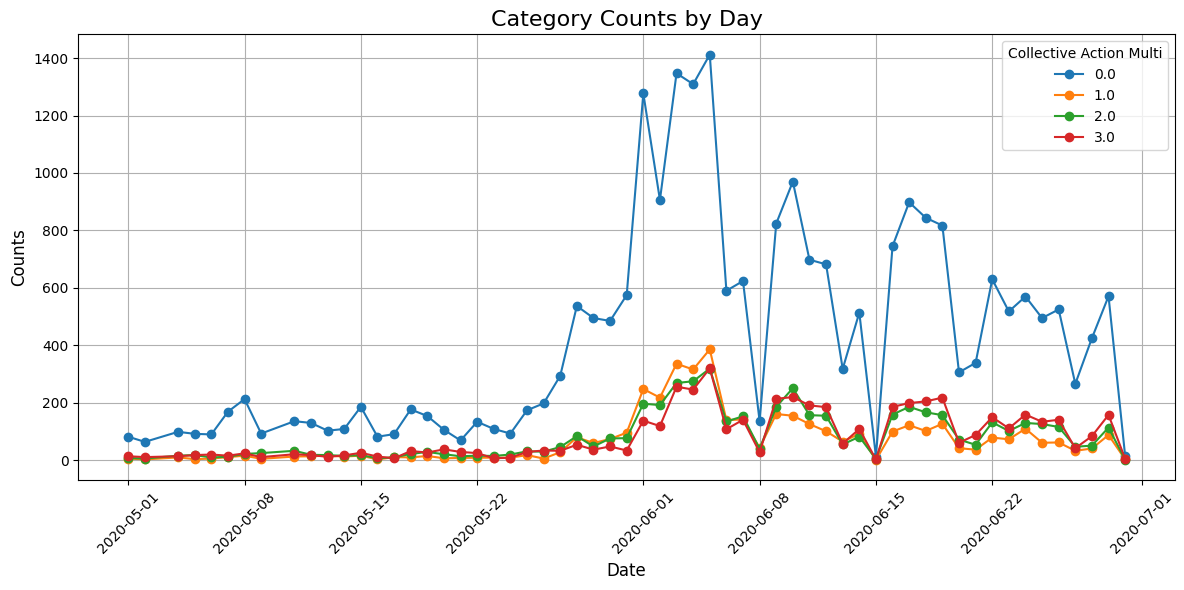

In [11]:
import matplotlib.pyplot as plt
category_counts_by_day.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Category Counts by Day', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.legend(title='Collective Action Multi', fontsize=10)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
category_counts_by_day.to_csv('../data/category_counts_by_day.csv', index=True)

In [8]:
len(episodes)

38916

In [ ]:
# Get unique episode_id values
unique_episode_ids = episodes['episode_id'].unique()

# Write to file
with open('../data/good_episode_ids.txt', 'w') as file:
    for episode_id in unique_episode_ids:
        file.write(f"{episode_id}\n")

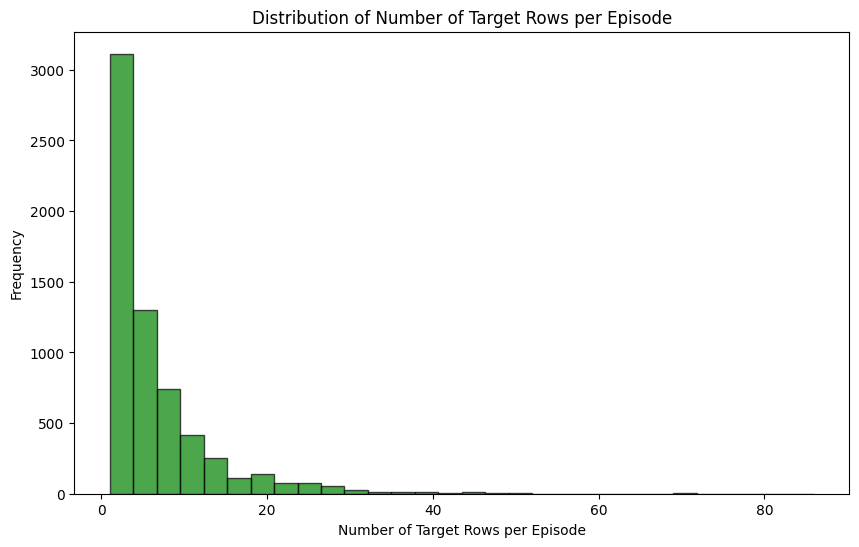

In [ ]:
import matplotlib.pyplot as plt

target_rows = episodes[(episodes['collectiveAction'] == 0) & (episodes['racialJustice'] == 1)]

target_counts = target_rows.groupby('episode_id').size()

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(target_counts, bins=30, color='green', edgecolor='k', alpha=0.7)
plt.xlabel('Number of Target Rows per Episode')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Target Rows per Episode')
plt.show()

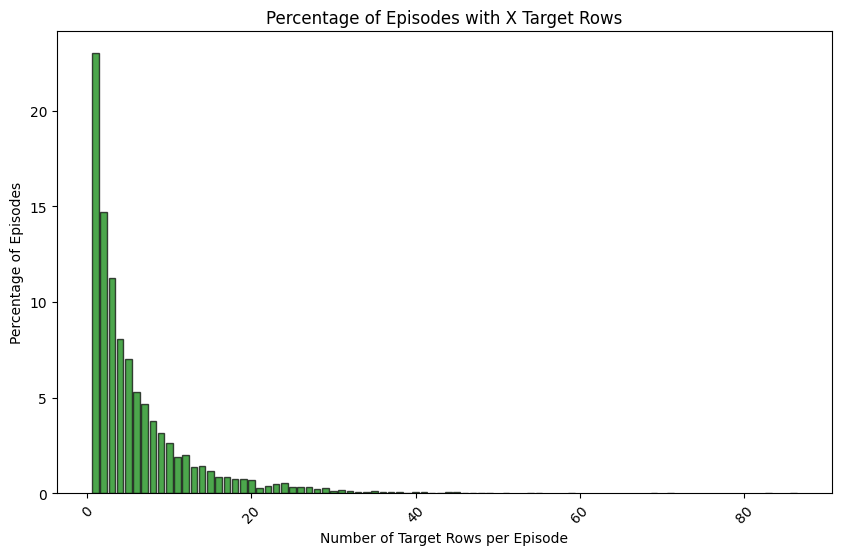

In [ ]:
import matplotlib.pyplot as plt

# Count target rows per episode
target_counts = episodes[(episodes['collectiveAction'] == 0) & (episodes['racialJustice'] == 1)].groupby('episode_id').size()

# Count how many episodes have each specific number of target rows
episode_frequencies = target_counts.value_counts(normalize=True) * 100  # Convert to percentage

# Sort by number of target rows
episode_frequencies = episode_frequencies.sort_index()

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.bar(episode_frequencies.index, episode_frequencies.values, color='green', edgecolor='k', alpha=0.7)
plt.xlabel('Number of Target Rows per Episode')
plt.ylabel('Percentage of Episodes')
plt.title('Percentage of Episodes with X Target Rows')
plt.xticks(rotation=45)  # Rotate x labels if needed for readability
plt.show()

## Burstiness (Kleinberg)
Kleinberg's algorithm models activity bursts in a time series as an infinite hidden Markov model.

- offsets: a list of time offsets (numeric)
- s: the base of the exponential distribution that is used for modeling the event frequencies
- gamma: coefficient for the transition costs between states

In [ ]:
# offsets = [4, 17, 23, 27, 33, 35, 37, 76, 77, 82, 84, 88, 90, 92]
# print(pybursts.kleinberg(offsets, s=2, gamma=0.1))

The output is supposed to be an array of intervals in which a burst of activity was detected. The first column denotes the level within the hierarchy; the second column the start value of the interval; the third column the end value. The first row is always the top-level activity (the complete interval from start to finish).

R version doesn't work either.

## Burstiness (Goh and Barabasi)

$B = \frac{\sigma - m}{\sigma + m}$

$\sigma$ is the standard deviation of inter-arrival times.
$m$ is the mean of inter-arrival times.

B has a value in the bounded range (−1,1), and its magnitude correlates with the signal’s burstiness:
- $B$ = 1 is the most bursty signal
- $B$ = 0 is neutral
- $B$ = −1 corresponds to a completely regular (periodic) signal

Or:
- $B$ = 0 → Poisson-like (random) behavior
- $B$ > 0 → Burstier (highly variable intervals)
- $B$ < 0 → Regular timing (almost periodic)

In [ ]:
import numpy as np

def burstiness(timepoints):
    if len(timepoints) < 2:
        return None  # Not enough data to compute burstiness
    
    interarrival_times = np.diff(timepoints)
    mean_ia = np.mean(interarrival_times)
    std_ia = np.std(interarrival_times)
    
    if mean_ia == 0 and std_ia == 0:
        return 0  # No variation
    
    return (std_ia - mean_ia) / (std_ia + mean_ia)

# Example usage
timepoints = [1, 3, 7, 8, 12]  # Example row indices as timepoints
B = burstiness(timepoints)
print("Burstiness:", B)

Burstiness: -0.35834730532397974


## Fano factor

$F = \frac{\sigma^2}{m}$

$\sigma^2$ is the variance of inter-arrival times.
$m$ is the mean of inter-arrival times.

- $F$ = 1 → Poisson process
- $F$ > 1 → More bursty
- $F$ < 1 → Regular intervals

In [ ]:
def fano_factor(timepoints):
    if len(timepoints) < 2:
        return None
    
    interarrival_times = np.diff(timepoints)
    mean_ia = np.mean(interarrival_times)
    var_ia = np.var(interarrival_times)
    
    return var_ia / mean_ia if mean_ia > 0 else None

# Example usage
F = fano_factor(timepoints)
print("Fano Factor:", F)

Fano Factor: 0.6136363636363636


##  Power-law Distribution of Inter-Event Times
- Exponent < 2 → Highly bursty
- Exponent > 3 → More regular

In [ ]:
import powerlaw

def fit_powerlaw(timepoints):
    if len(timepoints) < 2:
        return None
    
    interarrival_times = np.diff(timepoints)
    results = powerlaw.Fit(interarrival_times)
    return results.power_law.alpha  # Power-law exponent

# Example usage
alpha = fit_powerlaw(timepoints)
print("Power-law exponent:", alpha)

Calculating best minimal value for power law fit
Power-law exponent: 2.154156032711171


### Burstiness (debunked) for all episodes

In [ ]:
episodes_with_targets = episodes[(episodes['racialJustice'] == 1) & (episodes['collectiveAction'] == 0)]
episodes_with_targets_rj = episodes[(episodes['racialJustice'] == 1)]

In [ ]:
episode_counts = episodes_with_targets['episode_id'].value_counts()
num_episode_ids_with_at_least_3_rows = (episode_counts >= 3).sum()
print(f"Number of episode_id in episodes_with_targets with at least 3 rows: {num_episode_ids_with_at_least_3_rows}")

Number of episode_id in episodes_with_targets with at least 3 rows: 3966


In [ ]:
def burstiness(interarrival_times):
    """ Compute burstiness B = (std - mean) / (std + mean) """
    if len(interarrival_times) < 2:
        return None
    mean_ia = np.mean(interarrival_times)
    std_ia = np.std(interarrival_times)
    return (std_ia - mean_ia) / (std_ia + mean_ia) if (std_ia + mean_ia) != 0 else 0

# def fano_factor(interarrival_times):
#     """ Compute normalized Fano Factor: F = Var(interarrivals) / Mean(interarrivals) """
#     if len(interarrival_times) < 2:
#         return None
#     mean_ia = np.mean(interarrival_times)
#     var_ia = np.var(interarrival_times)
    
#     return var_ia / mean_ia if mean_ia > 0 else 0 
# 

# def powerlaw_exponent(interarrival_times):
#     """ Fit power-law to interarrival times and return the exponent α """
#     if len(interarrival_times) < 2:
#         return None
#     fit = powerlaw.Fit(interarrival_times)
#     return fit.power_law.alpha  # Extract power-law exponent

episodes_with_targets['time'] = pd.to_datetime(episodes_with_targets['time'])

# Compute metrics per episode
results = []
for episode_id, group in episodes_with_targets.groupby("episode_id"):
    group = group.sort_values(by="time")  # Ensure time order
    #interarrival_times = group["time"].diff().dt.total_seconds().dropna().values  # Compute interarrival times
    interarrival_times = group["time"].diff().dropna().dt.total_seconds().values
    
    if len(interarrival_times) > 1:  # Ensure at least two events
        B = burstiness(interarrival_times)
        #F = fano_factor(interarrival_times)
        #alpha = powerlaw_exponent(interarrival_times)
        #results.append({"episode_id": episode_id, "burstiness": B, "powerlaw_exponent": alpha})
        results.append({"episode_id": episode_id, "burstiness": B}) #, "fano_factor": F})

# Convert to DataFrame
burstiness_ca = pd.DataFrame(results)

# Drop NaNs if necessary
#burstiness.dropna(inplace=True)

# Display results
burstiness_ca.tail()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_70017/1150385883.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,episode_id,burstiness
3961,10488,-0.020000
3962,10489,-0.081759
3963,10490,0.070457
3964,10495,-0.500000
3965,10496,-0.024256


In [ ]:
len(burstiness_ca)

3966

In [ ]:
# Calculate the percentage of episodes with burstiness > 0
burstiness_positive_percentage = (burstiness_ca['burstiness'] > 0).mean() * 100
print(f"Percentage of episodes with burstiness > 0: {burstiness_positive_percentage:.2f}%")
num_burstiness_positive = (burstiness_ca['burstiness'] > 0).sum()
print(f"Number of episodes with burstiness > 0: {num_burstiness_positive}")

Percentage of episodes with burstiness > 0: 37.52%
Number of episodes with burstiness > 0: 1488


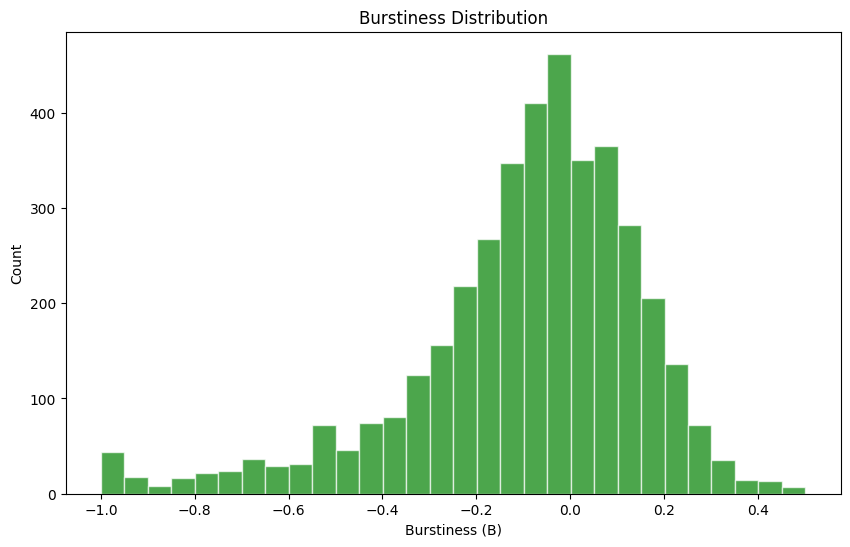

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(burstiness_ca["burstiness"], bins=30, alpha=0.7, color="green", edgecolor='white')
plt.title("Burstiness Distribution")
plt.xlabel("Burstiness (B)")
plt.ylabel("Count")
plt.show()

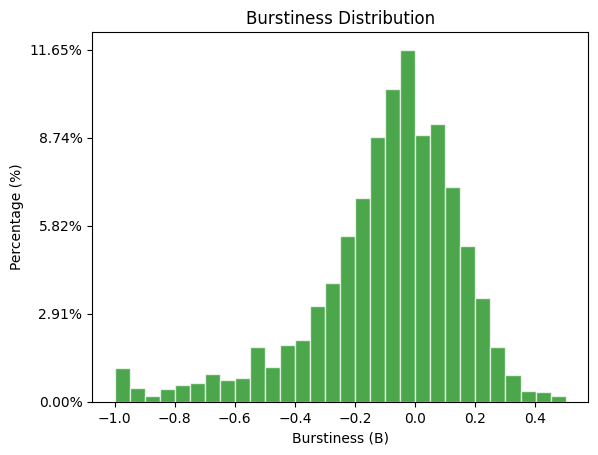

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the histogram values
values, bins, patches = plt.hist(burstiness_ca["burstiness"], bins=30, alpha=0.7, color="green", edgecolor='white')

# Calculate the total number of episodes
total_episodes = len(burstiness_ca["burstiness"])

# Convert counts to percentages
percentages = (values / total_episodes) * 100

# Get the current axis
ax = plt.gca()

# Set the y-axis ticks to the percentage values
ax.set_yticks(np.linspace(0, max(values), 5))
ax.set_yticklabels([f'{p:.2f}%' for p in np.linspace(0, max(percentages), 5)])

# Add the title and axis labels
plt.title("Burstiness Distribution")
plt.xlabel("Burstiness (B)")
plt.ylabel("Percentage (%)")

# Show the plot
plt.show()

Burstiness of racial justice sentences

In [ ]:
def burstiness(interarrival_times):
    """ Compute burstiness B = (std - mean) / (std + mean) """
    if len(interarrival_times) < 2:
        return None
    mean_ia = np.mean(interarrival_times)
    std_ia = np.std(interarrival_times)
    return (std_ia - mean_ia) / (std_ia + mean_ia) if (std_ia + mean_ia) != 0 else 0

episodes_with_targets_rj['time'] = pd.to_datetime(episodes_with_targets_rj['time'])
print(len(episodes_with_targets_rj))

results = []
for episode_id, group in episodes_with_targets_rj.groupby("episode_id"):
    group = group.sort_values(by="time")  # Ensure time order
    interarrival_times = group["time"].diff().dropna().dt.total_seconds().values
    
    if len(interarrival_times) > 1:  # Ensure at least two events
        B = burstiness(interarrival_times)
        results.append({"episode_id": episode_id, "burstiness": B}) #, "fano_factor": F})

# Convert to DataFrame
burstiness_rj = pd.DataFrame(results)

# Display results
burstiness_rj.tail()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_70017/2790323711.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



91619


,episode_id,burstiness
5415,10488,-0.091442
5416,10489,0.107883
5417,10490,0.090778
5418,10495,-0.051608
5419,10496,-0.028635


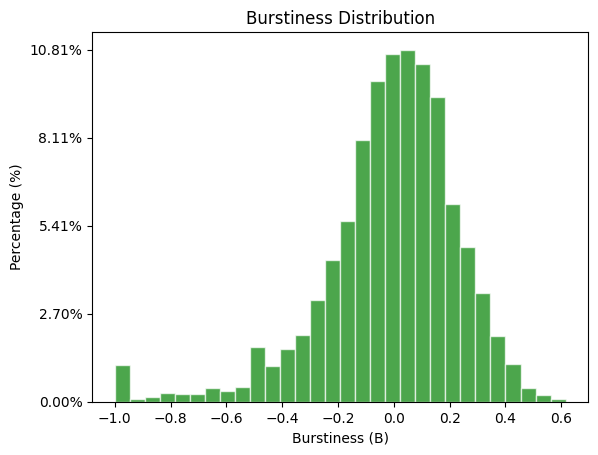

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the histogram values
values, bins, patches = plt.hist(burstiness_rj["burstiness"], bins=30, alpha=0.7, color="green", edgecolor='white')

# Calculate the total number of episodes
total_episodes = len(burstiness_rj["burstiness"])

# Convert counts to percentages
percentages = (values / total_episodes) * 100

# Get the current axis
ax = plt.gca()

# Set the y-axis ticks to the percentage values
ax.set_yticks(np.linspace(0, max(values), 5))
ax.set_yticklabels([f'{p:.2f}%' for p in np.linspace(0, max(percentages), 5)])

# Add the title and axis labels
plt.title("Burstiness Distribution")
plt.xlabel("Burstiness (B)")
plt.ylabel("Percentage (%)")

# Show the plot
plt.show()

In [ ]:
burstiness_rj.rename(columns={'burstiness': 'burstiness_rj'}, inplace=True)
merged_burstiness = pd.merge(burstiness_ca, burstiness_rj, on='episode_id', how='inner')
merged_burstiness.head()

,episode_id,burstiness,burstiness_rj
0,1,0.007833,0.082497
1,2,0.229476,0.312213
2,4,-0.088407,0.304671
3,5,0.042464,0.032973
4,6,-0.076923,-0.098508


## Bursty Dynamics analyzes temporal patterns in longitudinal data. 

This package implements the alternate *burstiness parameter* described in the paper ‘Measuring Burstiness for Finite Event Sequences’ by Kim, Eun-Kyeong, and Hang-Hyun Jo, and *memory coefficient* described in ‘Burstiness and Memory in Complex Systems’ by Goh, K.-I., and A.-L. Barabási.

We keep only sentences where both racial justice and collective action were identified. We treat each episode as a subject. We set the posting time of the podcast as the time for index 0 for each episode. Each subsequent sentence gets assigned time + 10 seconds.

In [ ]:
episodes_with_targets = episodes[(episodes['racialJustice'] == 1) & (episodes['collectiveAction'] == 0)]
episodes_with_targets.tail()

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,time
1537588,And this is what what the problem is is that t...,0,1,0.0,9997,2020-06-05 21:44:36
1537710,You have these skills that the average black m...,0,1,0.0,9997,2020-06-05 22:04:56
1537831,I just want us to keep in mind black people th...,0,1,0.0,9997,2020-06-05 22:25:06
1537844,And just make sure you support more black blac...,0,1,0.0,9997,2020-06-05 22:27:16
1537940,But friend ethnically diverse individuals so t...,0,1,0.0,9998,2020-05-31 05:58:12


In [ ]:
episode_counts = episodes_with_targets['episode_id'].value_counts()
valid_episode_ids = episode_counts[episode_counts >= 3].index
episodes_with_targets = episodes_with_targets[episodes_with_targets['episode_id'].isin(valid_episode_ids)]
episodes_with_targets.tail()

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,time
1537537,So the fact that black Twitter can get these n...,0,1,0.0,9997,2020-06-05 21:36:06
1537588,And this is what what the problem is is that t...,0,1,0.0,9997,2020-06-05 21:44:36
1537710,You have these skills that the average black m...,0,1,0.0,9997,2020-06-05 22:04:56
1537831,I just want us to keep in mind black people th...,0,1,0.0,9997,2020-06-05 22:25:06
1537844,And just make sure you support more black blac...,0,1,0.0,9997,2020-06-05 22:27:16


In [ ]:
score_df = calculate_scores(episodes_with_targets, subject_id = 'episode_id', time_col = 'time')
score_df.tail()

,episode_id,BP,MC
3961,10488,0.358754,NaN
3962,10489,-0.050353,-0.007183
3963,10490,0.420676,1.000000
3964,10495,-0.528595,NaN
3965,10496,-0.005281,-0.020918


In [ ]:
num_nan_mc = score_df['BP'].isna().sum()
print(f"Number of NaN values in score_df['BP']: {num_nan_mc}")

Number of NaN values in score_df['BP']: 0


In [ ]:
num_nan_mc = score_df['MC'].isna().sum()
print(f"Number of NaN values in score_df['MC']: {num_nan_mc}")

Number of NaN values in score_df['MC']: 772


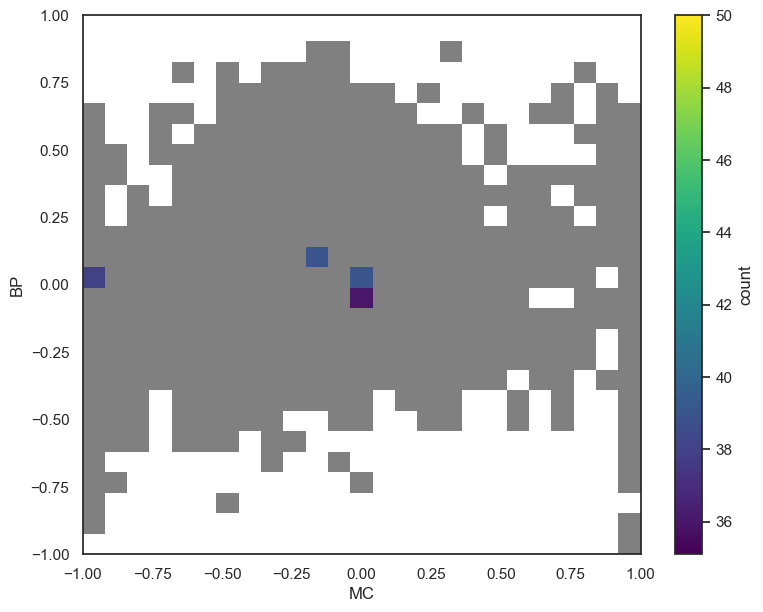

In [ ]:
gplot = gridplot(score_df, bins=25, lower_limit=50)
gplot

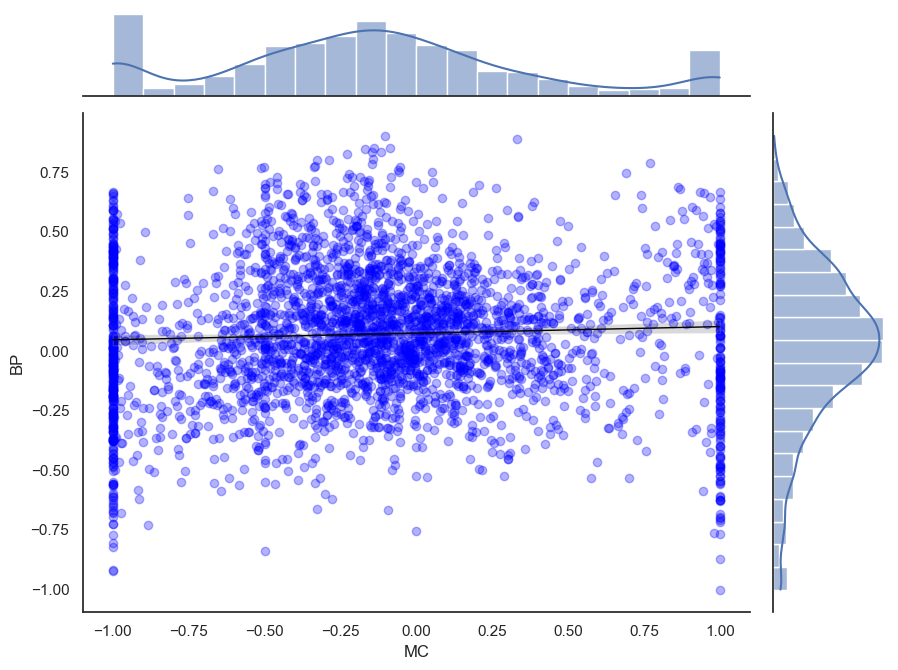

In [ ]:
score_df, scatter_plot = calculate_scores(episodes_with_targets, subject_id = 'episode_id', time_col = 'time', scatter=True)
scatter_plot

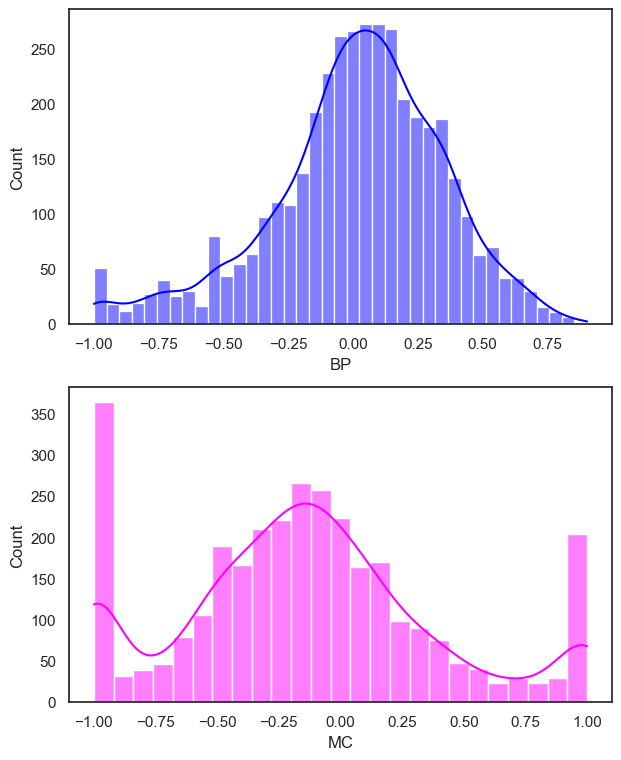

In [ ]:
score_df,hist_plots  = calculate_scores(episodes_with_targets, subject_id='episode_id', time_col='time', hist=True)
hist_plots

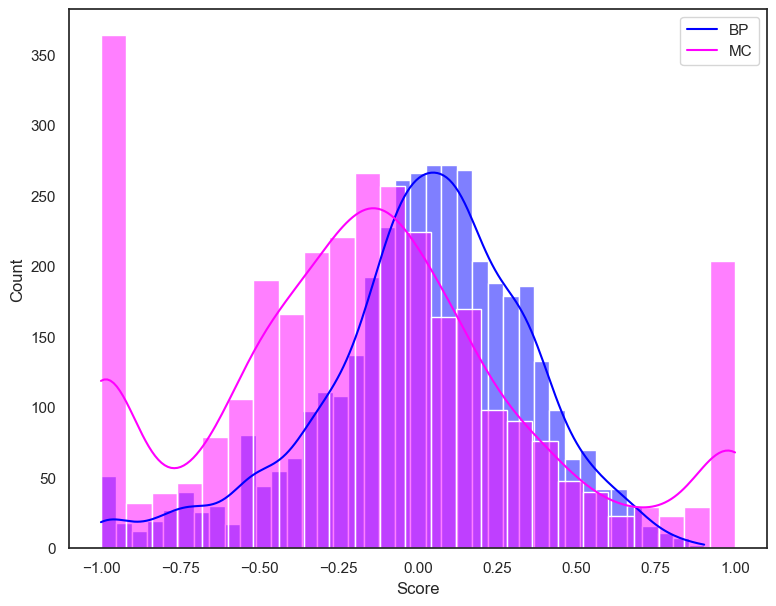

In [ ]:
# score_df,hist_plots  = calculate_scores(episodes_with_targets, subject_id='episode_id', time_col='time', hist=True)
score_df,scatter_plot,hist_plot  = calculate_scores(episodes_with_targets, subject_id='episode_id', time_col='time', scatter=True, hist='Both')
hist_plot

In [ ]:
# percentage_above_zero = (score_df["BP"] > 0).mean() * 100
# print(percentage_above_zero)
# plt.figure(figsize=(10, 6))
# plt.hist(score_df["BP"], bins=30, alpha=0.7, color="green", density=True)
# plt.title("Burstiness Distribution")
# plt.xlabel("Burstiness (A)")
# plt.ylabel("Percentage")
# plt.show()

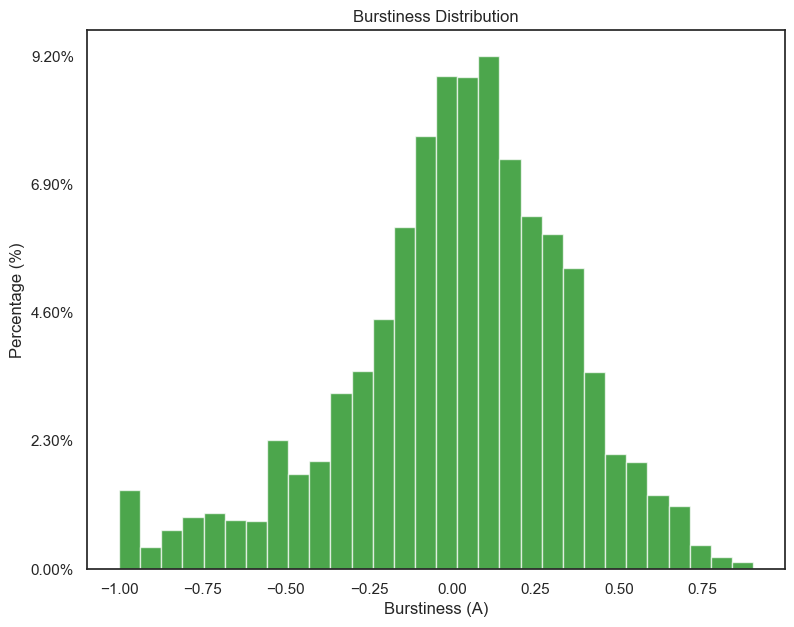

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the histogram values
values, bins, patches = plt.hist(score_df["BP"], bins=30, alpha=0.7, color="green", edgecolor='white')

# Calculate the total number of episodes
total_episodes = len(score_df["BP"])

# Convert counts to percentages
percentages = (values / total_episodes) * 100

# Get the current axis
ax = plt.gca()

# Set the y-axis ticks to the percentage values
ax.set_yticks(np.linspace(0, max(values), 5))
ax.set_yticklabels([f'{p:.2f}%' for p in np.linspace(0, max(percentages), 5)])

# Add the title and axis labels
plt.title("Burstiness Distribution")
plt.xlabel("Burstiness (A)")
plt.ylabel("Percentage (%)")

# Show the plot
plt.show()

In [ ]:
num_bp_greater_than_zero = (score_df["BP"] > 0).sum()
print(f"Number of entries in score_df['BP'] > 0: {num_bp_greater_than_zero}")

Number of entries in score_df['BP'] > 0: 2218


### Burstiness A for RJ

In [ ]:
episodes_with_targets = episodes[(episodes['racialJustice'] == 1)]
episodes_with_targets.tail()

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,time
1537818,"That will just happen, but it's always them ca...",1,1,NaN,9997,2020-06-05 22:22:56
1537831,I just want us to keep in mind black people th...,0,1,0.0,9997,2020-06-05 22:25:06
1537844,And just make sure you support more black blac...,0,1,0.0,9997,2020-06-05 22:27:16
1537853,"All that to say, recent conversations have had...",1,1,NaN,9998,2020-05-31 05:43:42
1537940,But friend ethnically diverse individuals so t...,0,1,0.0,9998,2020-05-31 05:58:12


In [ ]:
episode_counts = episodes_with_targets['episode_id'].value_counts()
valid_episode_ids = episode_counts[episode_counts >= 3].index
episodes_with_targets = episodes_with_targets[episodes_with_targets['episode_id'].isin(valid_episode_ids)]
episodes_with_targets.tail()

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,time
1537717,The fact that you are afraid when you go in th...,1,1,NaN,9997,2020-06-05 22:06:06
1537805,"Two black men are in the store, white woman, c...",1,1,NaN,9997,2020-06-05 22:20:46
1537818,"That will just happen, but it's always them ca...",1,1,NaN,9997,2020-06-05 22:22:56
1537831,I just want us to keep in mind black people th...,0,1,0.0,9997,2020-06-05 22:25:06
1537844,And just make sure you support more black blac...,0,1,0.0,9997,2020-06-05 22:27:16


In [ ]:
score_df = calculate_scores(episodes_with_targets, subject_id = 'episode_id', time_col = 'time')
score_df.tail()

,episode_id,BP,MC
5415,10488,-0.012130,-0.666527
5416,10489,0.186993,0.210041
5417,10490,0.247904,0.652268
5418,10495,0.031698,0.278780
5419,10496,-0.023925,0.431703


In [ ]:
num_nan_bp = score_df['MC'].isna().sum()
print(f"Number of NaN values in score_df['BP']: {num_nan_bp}")

Number of NaN values in score_df['BP']: 555


In [ ]:
# Calculate the percentage of episodes with burstiness > 0
burstiness_positive_percentage = (score_rj_df['BP_RJ'] > 0).mean() * 100
print(f"Percentage of episodes with burstiness > 0: {burstiness_positive_percentage:.2f}%")
num_burstiness_positive = (score_rj_df['BP_RJ'] > 0).sum()
print(f"Number of episodes with burstiness > 0: {num_burstiness_positive}")

Percentage of episodes with burstiness > 0: 64.87%
Number of episodes with burstiness > 0: 3516


In [ ]:
score_rj_df = score_df.rename(columns={'BP': 'BP_RJ', 'MC': 'MC_RJ'})
score_rj_df.tail()

,episode_id,BP_RJ,MC_RJ
5415,10488,-0.012130,-0.666527
5416,10489,0.186993,0.210041
5417,10490,0.247904,0.652268
5418,10495,0.031698,0.278780
5419,10496,-0.023925,0.431703


In [ ]:
merged_scores = pd.merge(score_df, score_rj_df, on='episode_id', how='inner')
merged_scores.head()

,episode_id,BP,MC,BP_RJ,MC_RJ
0,1,0.273512,1.000000,0.147643,0.436141
1,2,0.702369,-0.500000,0.675918,-0.156096
2,4,-0.069912,-0.257456,0.387872,0.121965
3,5,0.078847,0.064044,0.061144,0.033378
4,6,0.212183,NaN,0.004297,-0.500000


In [ ]:
from scipy import stats

t_stat, p_value = stats.ttest_rel(merged_scores['BP'], merged_scores['BP_RJ'])
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -21.68517284141982, P-value: 1.2353514029245842e-98


In [ ]:
# plt.figure(figsize=(14, 6))

# # Plot burstiness distribution
# plt.subplot(1, 2, 1)
# plt.hist(merged_scores['BP'], bins=30, alpha=0.7, color='blue', edgecolor='white')
# plt.title('Distribution of Burstiness')
# plt.xlabel('Burstiness (B)')
# plt.ylabel('Count')

# # Plot burstiness_rj distribution
# plt.subplot(1, 2, 2)
# plt.hist(merged_scores['BP_RJ'], bins=30, alpha=0.7, color='red', edgecolor='white')
# plt.title('Distribution of Burstiness RJ')
# plt.xlabel('Burstiness RJ (B)')
# plt.ylabel('Count')

# plt.tight_layout()
# plt.show()

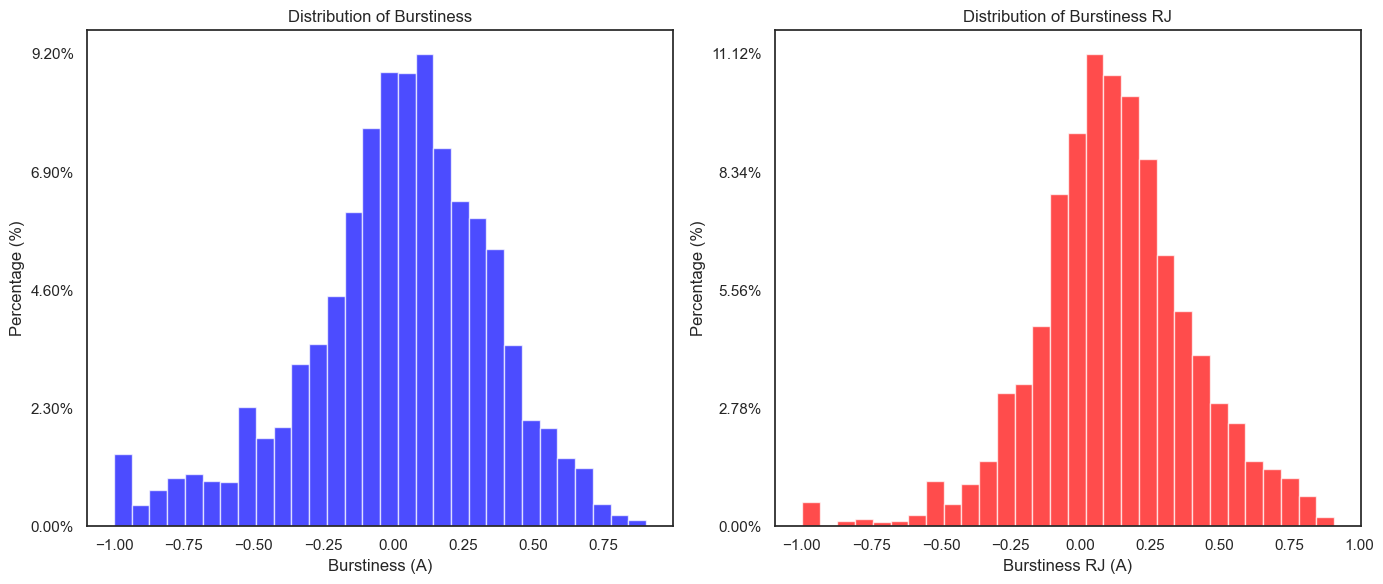

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting the figures
plt.figure(figsize=(14, 6))

# Plot burstiness distribution
plt.subplot(1, 2, 1)
values_bp, bins_bp, _ = plt.hist(merged_scores['BP'], bins=30, alpha=0.7, color='blue', edgecolor='white')
total_bp = len(merged_scores['BP'])
percentages_bp = (values_bp / total_bp) * 100

# Set the y-axis ticks to percentages
ax1 = plt.gca()
ax1.set_yticks(np.linspace(0, max(values_bp), 5))
ax1.set_yticklabels([f'{p:.2f}%' for p in np.linspace(0, max(percentages_bp), 5)])

plt.title('Distribution of Burstiness')
plt.xlabel('Burstiness (A)')
plt.ylabel('Percentage (%)')

# Plot burstiness_rj distribution
plt.subplot(1, 2, 2)
values_bp_rj, bins_bp_rj, _ = plt.hist(merged_scores['BP_RJ'], bins=30, alpha=0.7, color='red', edgecolor='white')
total_bp_rj = len(merged_scores['BP_RJ'])
percentages_bp_rj = (values_bp_rj / total_bp_rj) * 100

# Set the y-axis ticks to percentages
ax2 = plt.gca()
ax2.set_yticks(np.linspace(0, max(values_bp_rj), 5))
ax2.set_yticklabels([f'{p:.2f}%' for p in np.linspace(0, max(percentages_bp_rj), 5)])

plt.title('Distribution of Burstiness RJ')
plt.xlabel('Burstiness RJ (A)')
plt.ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_70017/75705159.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




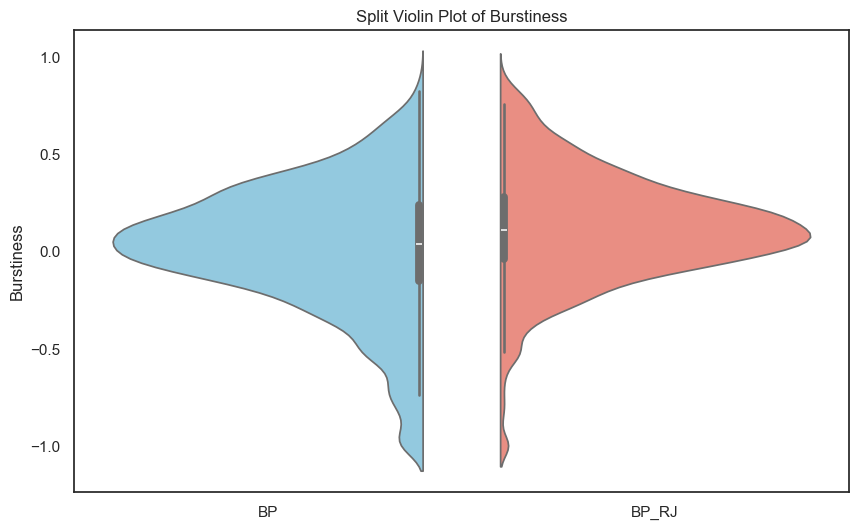

In [ ]:
plt.figure(figsize=(10, 6))

plot_data = merged_scores.melt(value_vars=['BP', 'BP_RJ'], 
                                   var_name='Category', value_name='Burstiness')

sns.violinplot(x='Category', y='Burstiness', data=plot_data, split=True, 
               palette={'BP': 'skyblue', 'BP_RJ': 'salmon'})

plt.title('Split Violin Plot of Burstiness')
plt.ylabel('Burstiness')
plt.xlabel('')
plt.show()

### Groups 

In [ ]:
score_df = score_df.merge(episodes_with_id[['episode_id', 'category1']], on='episode_id', how='left')
score_df.rename(columns={'category1': 'Group'}, inplace=True)
score_df.head()

,episode_id,BP,MC,Group
0,1,0.273512,1.000000,society
1,2,0.702369,-0.500000,education
2,4,-0.069912,-0.257456,news
3,5,0.078847,0.064044,news
4,6,0.212183,NaN,society


In [ ]:
score_df['Group'].value_counts()

Group
society       993
news          699
education     565
business      371
health        271
arts          204
sports        200
comedy        151
music          74
leisure        73
tv             73
kids           63
government     56
history        54
science        47
technology     32
fiction        13
true crime      6
games           1
politics        1
Name: count, dtype: int64

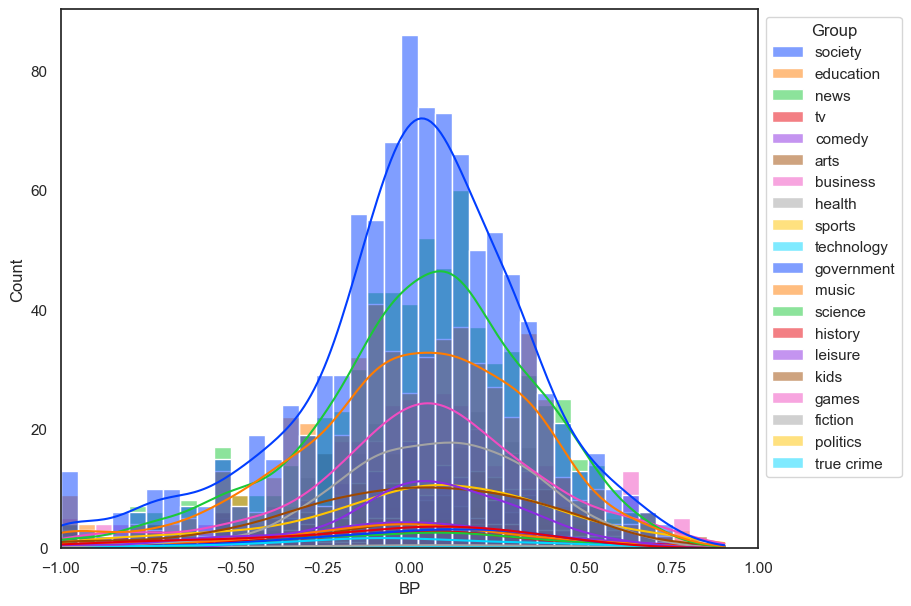

In [ ]:
histogram(score_df, hist='BP', set_axis=True, hue='Group')

### Detecting trains
- max_iet = Maximum distance between consecutive events in a train, in units specified by `time_unit`
- min_burst = Minimum number of events required to form a train. Default is 3.
- only_trains = True by default

A train shouldn't be made out of multiple episodes!

In [ ]:
train_df = train_detection(episodes_with_targets, subject_id = 'episode_id', time_col = 'time', max_iet=30, time_unit='seconds')
train_df.head(100) # 16 trains

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,time,train_id
147446,The next statement that I have for you guys is...,0,1,3.0,2,2020-06-03 15:03:00,1
147448,Aside from some people that are taking this as...,0,1,3.0,2,2020-06-03 15:03:20,1
147450,"I have classmates such as Renajia Franklin, wh...",0,1,3.0,2,2020-06-03 15:03:40,1
569986,"But what Trevor Noah then said was, you know, ...",0,1,0.0,5,2020-06-01 18:15:48,2
569987,"We as, as white people have been violating tha...",0,1,0.0,5,2020-06-01 18:15:58,2
...,...,...,...,...,...,...,...
149091,"Instead, we will be taking this time to reflec...",0,1,3.0,151,2020-06-05 01:00:10,1
149093,We joined the members of the K-pop community w...,0,1,3.0,151,2020-06-05 01:00:30,1
149095,If you'd like to join us in support of Black L...,0,1,1.0,151,2020-06-05 01:00:50,1
149228,And it is 100% that now I see what the Black L...,0,1,0.0,152,2020-06-14 04:36:12,3


In [ ]:
# Step 1: Get unique (episode_id, train_id) pairs
unique_combinations = train_df[['episode_id', 'train_id']].drop_duplicates()

# Step 2: Assign new unique train_id values
unique_combinations['new_train_id'] = range(1, len(unique_combinations) + 1)

# Step 3: Merge back to update train_id
train_df = train_df.merge(unique_combinations, on=['episode_id', 'train_id'], how='left')

# Step 4: Replace old train_id with new_train_id
train_df['train_id'] = train_df['new_train_id']

# Step 5: Drop the temporary column
train_df = train_df.drop(columns=['new_train_id'])

# Display the result
train_df.head(20)

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,time,train_id
0,The next statement that I have for you guys is...,0,1,3.0,2,2020-06-03 15:03:00,1
1,Aside from some people that are taking this as...,0,1,3.0,2,2020-06-03 15:03:20,1
2,"I have classmates such as Renajia Franklin, wh...",0,1,3.0,2,2020-06-03 15:03:40,1
3,"But what Trevor Noah then said was, you know, ...",0,1,0.0,5,2020-06-01 18:15:48,2
4,"We as, as white people have been violating tha...",0,1,0.0,5,2020-06-01 18:15:58,2
5,"Every time, frankly, that systematic racism di...",0,1,0.0,5,2020-06-01 18:16:08,2
6,You have to be anti-racist.,0,1,0.0,5,2020-06-01 18:19:48,3
7,You have to be committed to educating yourself...,0,1,2.0,5,2020-06-01 18:19:58,3
8,"But I believe that if, as a society, we contin...",0,1,1.0,5,2020-06-01 18:20:18,3
9,We can dismantle the fundamental inequities in...,0,1,1.0,5,2020-06-01 18:20:28,3


In [ ]:
# train_info_df = train_info(train_df, subject_id = 'episode_id', time_col = 'time', summary_statistic=True)

In [ ]:
# Get the length of unique train_id
num_unique_train_ids = train_df['train_id'].nunique()
print(f"Number of unique train_id: {num_unique_train_ids}")

# Provide summary statistics
train_id_counts = train_df['train_id'].value_counts()
summary_stats = train_id_counts.describe()
print(summary_stats)

Number of unique train_id: 1451
count    1451.000000
mean        3.529979
std         1.346117
min         3.000000
25%         3.000000
50%         3.000000
75%         4.000000
max        33.000000
Name: count, dtype: float64


In [ ]:
summary_stats = unique_train_counts.describe()
print(summary_stats)

count    1062.000000
mean        1.366290
std         0.809063
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         9.000000
Name: train_id, dtype: float64


In [ ]:
episodes_per_day = train_df.groupby('date')['episode_id'].nunique()
episodes_per_day_sorted = episodes_per_day.sort_values(ascending=False)
episodes_per_day_sorted.head()

date
2020-06-05    74
2020-06-04    64
2020-06-03    64
2020-06-10    51
2020-06-01    48
Name: episode_id, dtype: int64

In [ ]:
train_df['time'] = pd.to_datetime(train_df['time'])
train_df['date'] = train_df['time'].dt.date
trains_per_day = train_df.groupby('date')['train_id'].nunique().reset_index()
trains_per_day.columns = ['date', 'num_trains']
trains_per_day

,date,num_trains
0,2020-05-01,4
1,2020-05-02,3
2,2020-05-04,4
3,2020-05-05,5
4,2020-05-06,3
5,2020-05-07,1
6,2020-05-08,8
7,2020-05-09,6
8,2020-05-11,3
9,2020-05-12,8


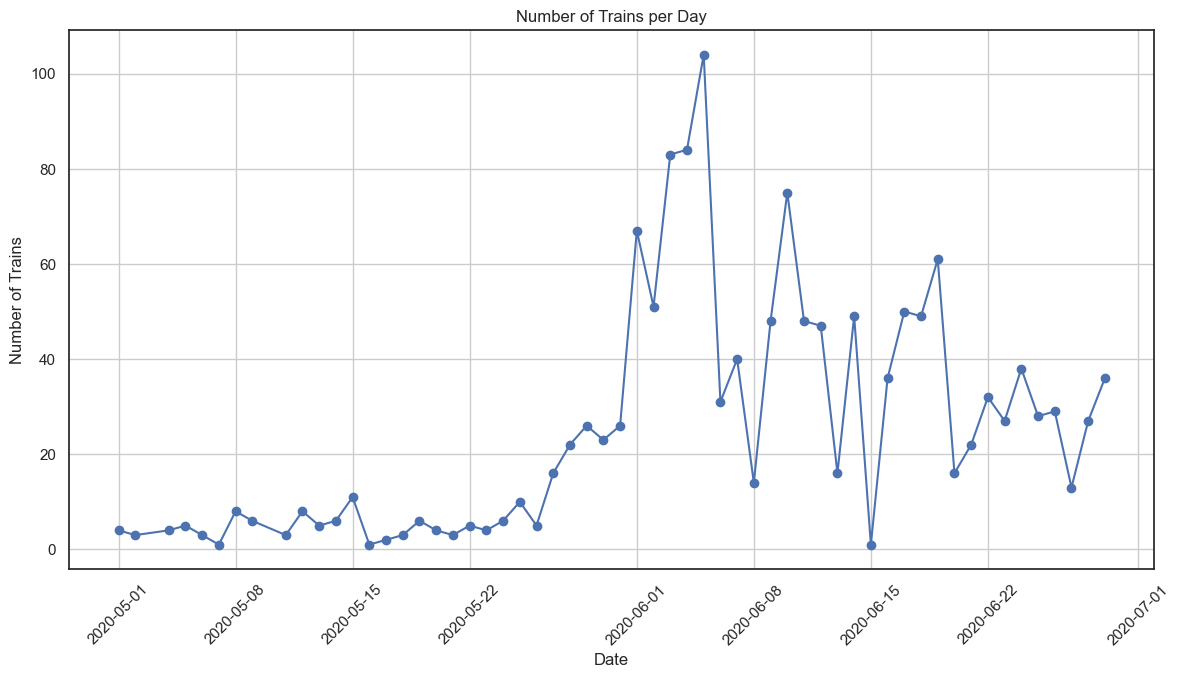

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(trains_per_day['date'], trains_per_day['num_trains'], marker='o', linestyle='-', color='b')
plt.xlabel('Date')
plt.ylabel('Number of Trains')
plt.title('Number of Trains per Day')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# train_info_df.head()

In [ ]:
# train_score_df = train_scores(train_df, subject_id = 'episode_id', time_col ='time', min_event_n= 5)
# train_score_df.head()

### New plot
For each episode: number of targets sentences and average IET between events. Plot and find clusters

In [ ]:
# Filter target rows
target_rows = episodes[(episodes['racialJustice'] == 1) & (episodes['collectiveAction'] == 0)]

# Group by episode_id and calculate the number of target sentences and average number of rows between target rows
targets_and_breaks = target_rows.groupby('episode_id').apply(
    lambda group: pd.Series({
        'num_target_sentences': len(group),
        'avg_rows_between_targets': group.index.to_series().diff().mean() if len(group) > 1 else 0
    })
).reset_index()

# Display the resulting dataframe
targets_and_breaks.head()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_70017/3591982762.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,episode_id,num_target_sentences,avg_rows_between_targets
0,1,4.0,141.666667
1,2,5.0,38.000000
2,4,14.0,44.307692
3,5,25.0,5.750000
4,6,3.0,7.000000


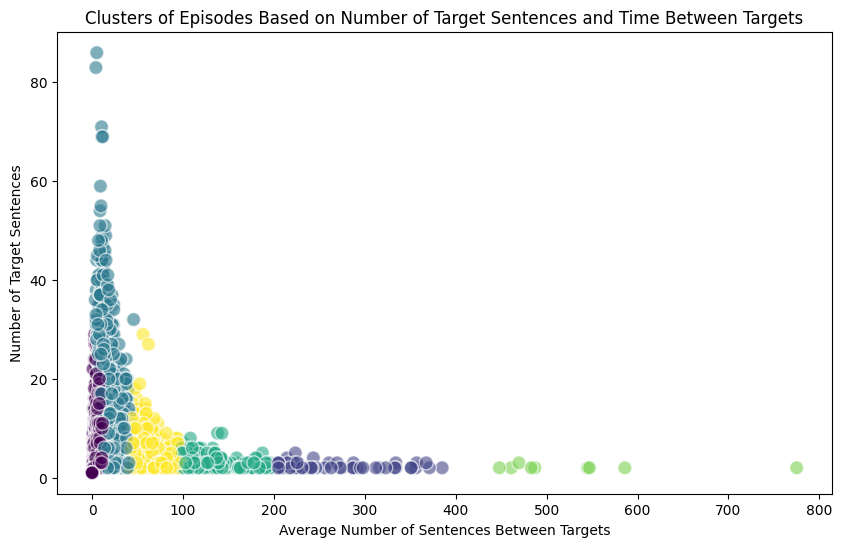

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = targets_and_breaks[['avg_rows_between_targets', 'num_target_sentences']]

kmeans = KMeans(n_clusters=6, random_state=0).fit(X)
targets_and_breaks['cluster'] = kmeans.labels_

plt.figure(figsize=(10, 6))
plt.scatter(X['avg_rows_between_targets'], X['num_target_sentences'], c=targets_and_breaks['cluster'], cmap='viridis', alpha=0.6, edgecolors='w', s=100)
plt.xlabel('Average Number of Sentences Between Targets')
plt.ylabel('Number of Target Sentences')
plt.title('Clusters of Episodes Based on Number of Target Sentences and Time Between Targets')
#plt.colorbar(label='Cluster')
plt.show()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_70017/1196213704.py:9: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



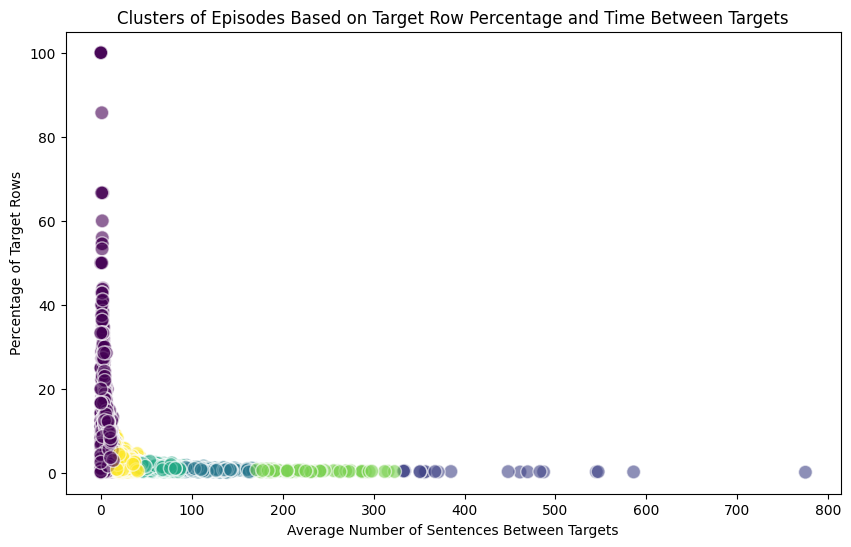

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Filter target rows
target_rows = episodes[(episodes['racialJustice'] == 1) & (episodes['collectiveAction'] == 0)]

# Compute target row percentage and avg distance between targets
targets_and_breaks = target_rows.groupby('episode_id').apply(
    lambda group: pd.Series({
        'percentage_target_rows': len(group) / episodes[episodes['episode_id'] == group.name].shape[0] * 100,
        'avg_rows_between_targets': group.index.to_series().diff().mean() if len(group) > 1 else 0
    })
).reset_index()

# Display the resulting dataframe
targets_and_breaks.head()

# Clustering
X = targets_and_breaks[['avg_rows_between_targets', 'percentage_target_rows']]

kmeans = KMeans(n_clusters=6, random_state=0).fit(X)
targets_and_breaks['cluster'] = kmeans.labels_

# Plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(X['avg_rows_between_targets'], X['percentage_target_rows'], c=targets_and_breaks['cluster'], cmap='viridis', alpha=0.6, edgecolors='w', s=100)
plt.xlabel('Average Number of Sentences Between Targets')
plt.ylabel('Percentage of Target Rows')
plt.title('Clusters of Episodes Based on Target Row Percentage and Time Between Targets')
plt.show()

In [ ]:
# Count occurrences of each category in collectiveActionMulti per episode
cluster_data = target_rows.groupby(['episode_id', 'collectiveActionMulti']).size().unstack(fill_value=0)

# Rename columns for clarity
cluster_data.columns = [f'count_CA_{col}' for col in cluster_data.columns]

# Merge back with the original episodes dataset (optional, if you need other features)
episodes_clustered = episodes.merge(cluster_data, on='episode_id', how='left').fillna(0)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare features for clustering
features = cluster_data.values  # Only count columns
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # Adjust number of clusters as needed
clusters = kmeans.fit_predict(features_scaled)

# Add cluster labels to the DataFrame
cluster_data['cluster'] = clusters

# Merge back to the full dataset
episodes_clustered = episodes.merge(cluster_data[['cluster']], on='episode_id', how='left').fillna(-1)

In [ ]:
episodes_clustered = episodes.merge(cluster_data[['cluster']], on='episode_id', how='left')
episodes_clustered = episodes_clustered.dropna(subset=['cluster'])  # Remove NaN values
episodes_clustered = episodes_clustered[episodes_clustered['cluster'] != -1]  # Remove -1 values
episodes_clustered = episodes_clustered[(episodes_clustered['collectiveAction'] == 0) & (episodes_clustered['racialJustice'] == 1)]
episodes_clustered

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,time,cluster
21,"So my mother back in 1978, created a private s...",0,1,2.0,1,2020-06-17 23:35:50,2
24,"My father, who's a mental health professional,...",0,1,3.0,1,2020-06-17 23:36:20,2
106,"And I think that the 70s, 80s was really that ...",0,1,0.0,1,2020-06-17 23:50:00,2
446,"Well, and I'm gonna say too that if we problem...",0,1,0.0,1,2020-06-18 00:46:40,2
518,You start to wonder if it should be all black ...,0,1,0.0,11,2020-06-09 19:49:17,0
...,...,...,...,...,...,...,...
1536911,And this is what what the problem is is that t...,0,1,0.0,9997,2020-06-05 21:44:36,2
1537033,You have these skills that the average black m...,0,1,0.0,9997,2020-06-05 22:04:56,2
1537154,I just want us to keep in mind black people th...,0,1,0.0,9997,2020-06-05 22:25:06,2
1537167,And just make sure you support more black blac...,0,1,0.0,9997,2020-06-05 22:27:16,2


In [ ]:
category_counts = episodes_clustered['collectiveActionMulti'].value_counts()
print(category_counts)

collectiveActionMulti
0.0    24923
3.0     4955
2.0     4852
1.0     4186
Name: count, dtype: int64


In [ ]:
cluster_data.rename(columns={'count_CA_0.0': 'problem_solution'}, inplace=True)
cluster_data.rename(columns={'count_CA_1.0': 'call_to_action'}, inplace=True)
cluster_data.rename(columns={'count_CA_2.0': 'intention'}, inplace=True)
cluster_data.rename(columns={'count_CA_3.0': 'execution'}, inplace=True)

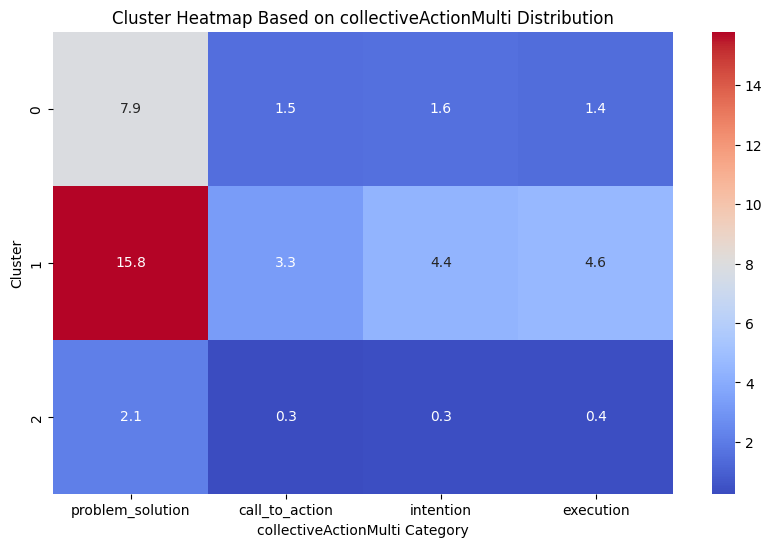

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pivot table for the heatmap
heatmap_data = cluster_data.set_index('cluster').groupby('cluster').mean()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt=".1f")

plt.title("Cluster Heatmap Based on collectiveActionMulti Distribution")
plt.xlabel("collectiveActionMulti Category")
plt.ylabel("Cluster")
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# from mpl_toolkits.mplot3d import Axes3D

# # Sample Data (Replace with your actual DataFrame)
# df = cluster_data  

# # Define colors for clusters
# unique_clusters = df['cluster'].unique()
# palette = sns.color_palette("husl", len(unique_clusters))
# color_map = {cluster: palette[i] for i, cluster in enumerate(unique_clusters)}

# # Create 3D scatter plot
# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# # Scatter plot using 'call_to_action', 'intention', 'execution'
# sc = ax.scatter(df['call_to_action'], df['intention'], df['execution'], 
#                 c=[color_map[c] for c in df['cluster']], s=50, alpha=0.8)

# # Labels
# ax.set_xlabel("Call to Action")
# ax.set_ylabel("Intention")
# ax.set_zlabel("Execution")
# ax.set_title("3D Cluster Visualization")

# plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(df, 
                    x='call_to_action', 
                    y='intention', 
                    z='execution', 
                    color='cluster', 
                    opacity=0.8)

fig.show()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_70017/3548525846.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



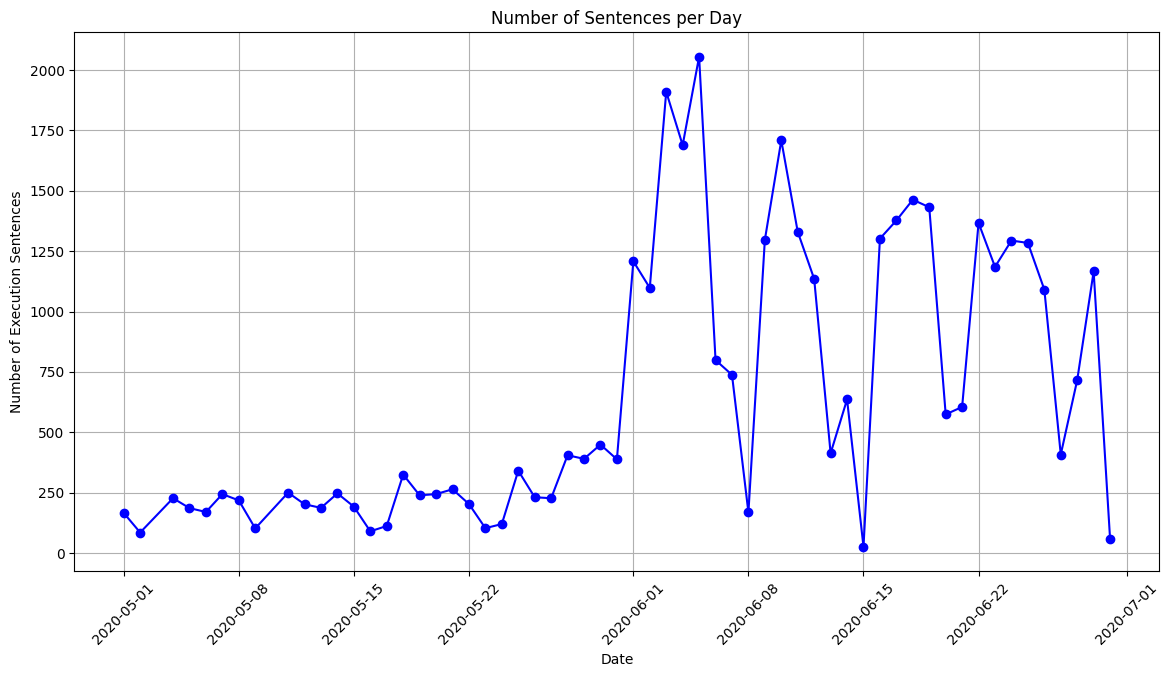

In [ ]:
# episodes_clustered_ca3['date'] = pd.to_datetime(episodes_clustered_ca3['time']).dt.date
# execution_per_day = episodes_clustered_ca3.groupby('date').size().reset_index(name='num_sentences')

# plt.figure(figsize=(14, 7))
# plt.plot(execution_per_day['date'], execution_per_day['num_sentences'], marker='o', linestyle='-', color='b')
# plt.xlabel('Date')
# plt.ylabel('Number of Execution Sentences')
# plt.title('Number of Sentences per Day')
# plt.xticks(rotation=45)
# plt.grid(True)
# plt.show()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_70017/2926838629.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_70017/2926838629.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_70017/2926838629.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

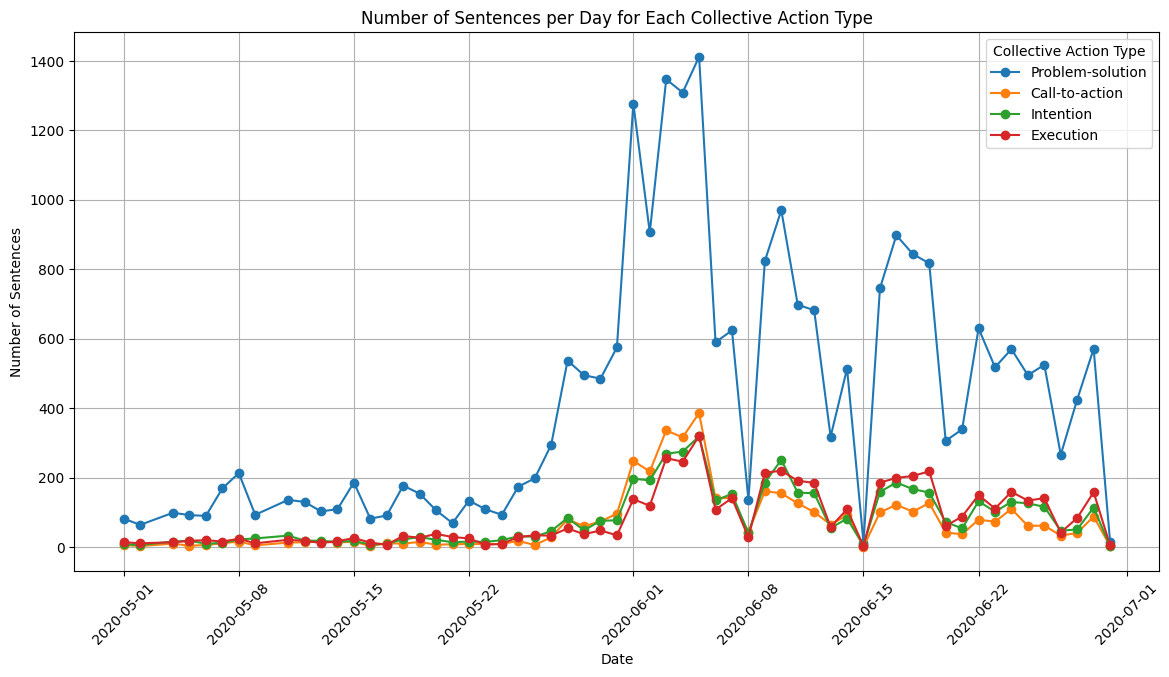

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter the DataFrames based on collectiveActionMulti values
episodes_clustered_ca0 = episodes_clustered[episodes_clustered['collectiveActionMulti'] == 0]
episodes_clustered_ca1 = episodes_clustered[episodes_clustered['collectiveActionMulti'] == 1]
episodes_clustered_ca2 = episodes_clustered[episodes_clustered['collectiveActionMulti'] == 2]
episodes_clustered_ca3 = episodes_clustered[episodes_clustered['collectiveActionMulti'] == 3]

# Define a function to get the number of occurrences per day
def get_daily_count(df, label):
    df['date'] = pd.to_datetime(df['time']).dt.date
    daily_count = df.groupby('date').size().reset_index(name='num_sentences')
    daily_count['action'] = label  # Add a column to differentiate the CA group
    return daily_count

# Get daily counts for each collective action group
trains_per_day_ca0 = get_daily_count(episodes_clustered_ca0, 'Problem-solution')
trains_per_day_ca1 = get_daily_count(episodes_clustered_ca1, 'Call-to-action')
trains_per_day_ca2 = get_daily_count(episodes_clustered_ca2, 'Intention')
trains_per_day_ca3 = get_daily_count(episodes_clustered_ca3, 'Execution')

# Combine the dataframes
trains_per_day = pd.concat([trains_per_day_ca0, trains_per_day_ca1, trains_per_day_ca2, trains_per_day_ca3])

# Plotting
plt.figure(figsize=(14, 7))
for action, label in zip(['Problem-solution', 'Call-to-action', 'Intention', 'Execution'], 
                         ['Problem-solution', 'Call-to-action', 'Intention', 'Execution']):
    daily_data = trains_per_day[trains_per_day['action'] == action]
    plt.plot(daily_data['date'], daily_data['num_sentences'], marker='o', linestyle='-', label=label)

plt.xlabel('Date')
plt.ylabel('Number of Sentences')
plt.title('Number of Sentences per Day for Each Collective Action Type')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Collective Action Type')
plt.show()